In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv('../data/2026-02-23.csv', sep=';')
df['price'] = df['price'].str.replace(',', '.').astype(float)
df.columns

Index(['product_code', 'EAN', 'price', 'price €', 'amount', 'realizationTime',
       'productionYear', 'seller', 'actualization', 'is_retreaded', 'producer',
       'size', 'width', 'rim', 'profil', 'speed', 'capacity', 'season', 'ROF',
       'XL', 'name', 'type', 'date'],
      dtype='str')

In [13]:
df['type'].value_counts()
df_reduced = df[df['type'].isin(['Osobowe', 'Motocykle', '4x4/SUV'])].copy()

df_reduced = df_reduced[df_reduced['seller'].isin(['Olek Motocykle Sp. z o.o. Sp. k.', 'LATEX OPONY Sp. z o.o.', 'Latex Serwis Sp. z o.o.', 'MOTO-OIL-GUM CENTRUM MOTORYZACYJNE Sylwia Seliga'])].copy()
df_reduced = df_reduced.loc[:, ['product_code', 'producer', 'seller', 'name', 'size', 'season', 'price']]

In [14]:
df_reduced.to_excel('../data/for_piotr/reduced_data.xlsx', index=False)

In [15]:
df['seller'].value_counts()

seller
Inforeifen Sp. z o.o.                        78050
IPC Chmal sp.k.                              75819
Moto Budrex Sp. z o.o.                       74489
InMoto Sp. z o.o.                            65512
Plusgum Łukasz Pyrc                          58021
                                             ...  
Tuning World Tomasz Matlanga                     1
Truck-Gum Waldemar Olkowicz                      1
usługi motoryzacyjne Przemysław Snakowski        1
Trafica Michał Kurowski                          1
CZAUSTON Piotr Czaus                             1
Name: count, Length: 378, dtype: int64

In [11]:
# for each company in 'producer', create a df {pruducer_name}
producers = df_reduced['producer'].unique()
producer_dfs = {}
for producer in producers:
    producer_dfs[producer] = df_reduced[df_reduced['producer'] == producer].copy()

In [14]:
# Save each producer df to an Excel file named {producer_name}.xlsx
for producer, producer_df in producer_dfs.items():
    producer_df.to_excel(f'../data/for_piotr/{producer}.xlsx', index=False)

KeyboardInterrupt: 

In [ ]:
car = df[df['type'].isin(['Osobowe', '4x4/SUV'])]
moto = df[df['type'] == 'Motocykle']

In [5]:
df_pirelli_car = car[car['producer'] == 'Pirelli']
df_pirelli_car

,product_code,EAN,price,price €,amount,realizationTime,productionYear,seller,actualization,is_retreaded,...,rim,profil,speed,capacity,season,ROF,XL,name,type,date
51,2553200,8019227255324,420.00,"99,59",12,1,2021.0,MJK Serwis Michał Górski,14.02.2026 08:14,0,...,19.0,35.0,V,91,Zima,0,1,Winter Sottozero 3 XL FR RO1,Osobowe,23.02.2026
53,2751700,8019227275179,725.00,"171,91",14,1,2022.0,MAGIC TYRES EXPORT MAGOŃ ROBERT,23.02.2026 09:33,0,...,20.0,45.0,V,110,Zima,1,1,Scorpion Winter XL FR R-F *,4x4/SUV,23.02.2026
56,3940900,8019227394092,800.00,"189,69",1,1,2024.0,Auto Wul Mac Maciej Tournier,23.02.2026 08:57,0,...,20.0,40.0,V,99,Zima,0,1,P Zero Winter XL FR * MO,Osobowe,23.02.2026
71,2553200,8019227255324,510.00,"120,93",42,1,2021.0,eOponyFelgi GRZEGORZ NIEZGODA,19.02.2026 10:47,0,...,19.0,35.0,V,91,Zima,0,1,Winter Sottozero 3 XL FR RO1,Osobowe,23.02.2026
88,4602000,8019227460209,423.02,"100,31",30,2,NaN,Moto Budrex Sp. z o.o.,23.02.2026 14:10,0,...,17.0,55.0,V,98,Zima,0,1,CINTURATO WINTER XL,Osobowe,23.02.2026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1085014,4244200,8019227424423,350.09,"83,01",40,4,NaN,IPC Chmal sp.k.,23.02.2026 14:12,0,...,18.0,40.0,Y,92,Lato,0,1,P ZERO (PZ5) XL FR,Osobowe,23.02.2026
1085035,4260800,8019227426083,890.47,"211,15",20,4,NaN,IPC Chmal sp.k.,23.02.2026 14:12,0,...,21.0,40.0,V,100,Lato,0,1,P ZERO PZ4 L.S. XL FR VOL,4x4/SUV,23.02.2026
1085039,3573800,8019227357387,1746.95,"414,23",17,4,NaN,IPC Chmal sp.k.,23.02.2026 14:11,0,...,21.0,30.0,Y,105,Lato,0,1,P ZERO PZ4 S.C. XL FR F01,Osobowe,23.02.2026
1085081,3743900,8019227374391,775.41,"183,86",8,4,NaN,IPC Chmal sp.k.,23.02.2026 14:11,0,...,20.0,60.0,H,108,Zima,0,1,P Zero Winter XL FR * ELT,Osobowe,23.02.2026


In [6]:
# compare mean price offers by seller grouping by size, width, rim, profile, speed and capacity 
grouped_car = car.groupby(['seller','size', 'width', 'rim', 'profil', 'speed', 'capacity', 'season', 'name']).agg({'price': 'mean'}).reset_index()
grouped_car = grouped_car.sort_values(by=['size', 'width', 'rim', 'profil', 'speed', 'capacity', 'season', 'name', 'price'], ascending=False)
grouped_car

,seller,size,width,rim,profil,speed,capacity,season,name,price
397479,JAN GRZEJDA INVESTMENT,6.4/7R13,6.4,13.0,7.0,S,87,Lato,Sprint Classic,596.01
229401,IPC Chmal sp.k.,6.4/7R13,6.4,13.0,7.0,S,87,Lato,Sprint Classic,557.43
583406,Plusgum Łukasz Pyrc,6.4/7R13,6.4,13.0,7.0,S,87,Lato,Sprint Classic,554.54
276443,InMoto Sp. z o.o.,6.4/7R13,6.4,13.0,7.0,S,87,Lato,SPRINT CLASSIC,549.00
397478,JAN GRZEJDA INVESTMENT,6.4/7R13,6.4,13.0,7.0,S,87,Lato,SPRINT CLASSIC,536.50
...,...,...,...,...,...,...,...,...,...,...
276444,Inforeifen Sp. z o.o.,115/70R15,115.0,15.0,70.0,M,90,Lato,K801,211.96
182434,IPC Chmal sp.k.,115/70R15,115.0,15.0,70.0,M,90,Lato,K801,199.84
58481,Digito Group Sp. z o.o.,115/70R15,115.0,15.0,70.0,M,90,Lato,K801,181.00
229419,InMoto Sp. z o.o.,115/70R15,115.0,15.0,70.0,M,90,Lato,K801,145.00


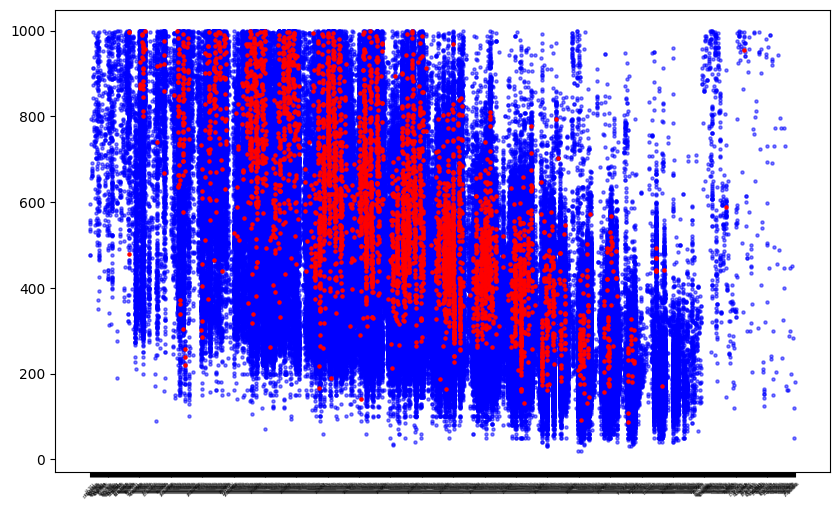

In [7]:

# plot price vs size for each seller, highlighting MOTO-OIL-GUM CENTRUM MOTORYZACYJNE Sylwia Seliga in red and the rest in blue
# make sure the red dots are on top of the blue dots
# only plot 0-1000 price range
# set x ticks angle to 45 degrees
plt.figure(figsize=(10, 6))
plt.xticks(rotation=45, size=2)
for seller in grouped_car['seller'].unique():
    seller_data = grouped_car[grouped_car['seller'] == seller]
    seller_data = seller_data[(seller_data['price'] >= 0) & (seller_data['price'] <= 1000)]
    if seller == 'MOTO-OIL-GUM CENTRUM MOTORYZACYJNE Sylwia Seliga':
        plt.scatter(seller_data['size'], seller_data['price'], color='red', label=seller, zorder=2, s=5)
    else:
        plt.scatter(seller_data['size'], seller_data['price'], color='blue', label=seller, alpha=0.5, zorder=1, s=5)


In [8]:
grouped_moto = moto.groupby(['seller','size', 'width', 'rim', 'profil', 'speed', 'capacity', 'season', 'name']).agg({'price': 'mean'}).reset_index()
grouped_moto = grouped_moto.sort_values(by=['size', 'width', 'rim', 'profil', 'speed', 'capacity', 'name', 'price'], ascending=False)
grouped_moto

,seller,size,width,rim,profil,speed,capacity,season,name,price
29451,Moto Budrex Sp. z o.o.,90/90V21,90.0,21.0,90.0,V,54,Lato,TRAILMAX MERIDIAN TL FRONT,439.670
12179,IPC Chmal sp.k.,90/90V21,90.0,21.0,90.0,V,54,Lato,TRAILMAX MERIDIAN TL FRONT,419.030
2188,Delticom AG,90/90V21,90.0,21.0,90.0,V,54,Lato,TRAILMAX MERIDIAN TL FRONT,414.100
18878,Inforeifen Sp. z o.o.,90/90V21,90.0,21.0,90.0,V,54,Lato,TRAILMAX MERIDIAN TL FRONT,410.535
8598,GPD a.s.,90/90V21,90.0,21.0,90.0,V,54,Lato,TRAILMAX MERIDIAN TL FRONT,407.620
...,...,...,...,...,...,...,...,...,...,...
5299,FHU Adam Łowigus,100/100-17,100.0,17.0,100.0,M,58,Lato,Maxxcross IT (M-7305) REAR NHS,239.530
12180,InMoto Sp. z o.o.,100/100-17,100.0,17.0,100.0,M,58,Lato,Maxxcross IT (M-7305) REAR NHS,225.000
465,Delticom AG,100/100-17,100.0,17.0,100.0,M,58,Lato,Maxxcross IT (M-7305) REAR NHS,215.490
2967,Enis S.A (dawniej: Enis sp. z o.o sp.k),100/100-17,100.0,17.0,100.0,M,58,Lato,Maxxcross IT (M-7305) REAR NHS,211.540


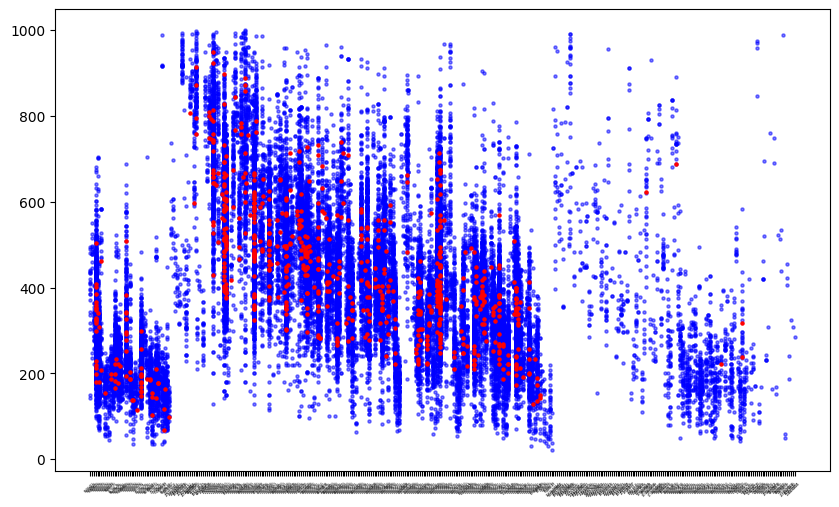

In [9]:
# plot price vs size for each seller, highlighting MOTO-OIL-GUM CENTRUM MOTORYZACYJNE Sylwia Seliga in red and the rest in blue
# make sure the red dots are on top of the blue dots
# only plot 0-1000 price range
# set x ticks angle to 45 degrees
plt.figure(figsize=(10, 6))
plt.xticks(rotation=45, size=2)
for seller in grouped_moto['seller'].unique():
    seller_data = grouped_moto[grouped_moto['seller'] == seller]
    seller_data = seller_data[(seller_data['price'] >= 0) & (seller_data['price'] <= 1000)]
    if seller == 'MOTO-OIL-GUM CENTRUM MOTORYZACYJNE Sylwia Seliga':
        plt.scatter(seller_data['size'], seller_data['price'], color='red', label=seller, zorder=2, s=5)
    else:
        plt.scatter(seller_data['size'], seller_data['price'], color='blue', label=seller, alpha=0.5, zorder=1, s=5)
